<a href="https://colab.research.google.com/github/reash-08/RoadAccident-SeverityPredictor/blob/main/Day_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# DAY 6 - TASK 1

import pandas as pd


# Update this path to your file in Google Drive
file_path = '/content/drive/My Drive/accident_50k.csv'

# Load dataset from Google Drive
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully from Google Drive")

# Shape
print("\nDataset Shape:")
print(df.shape)

# Data Types
print("\nColumn Types:")
print(df.dtypes)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Dataset Loaded Successfully from Google Drive

Dataset Shape:
(50000, 34)

Column Types:
Accident_Index                                  object
1st_Road_Class                                  object
1st_Road_Number                                float64
2nd_Road_Class                                  object
2nd_Road_Number                                float64
Accident_Severity                               object
Carriageway_Hazards                             object
Date                                            object
Day_of_Week                                     object
Did_Police_Officer_Attend_Scene_of_Accident    float64
Junction_Control                                object
Junction_Detail                                 object
Latitude                                       float64
Light_Conditions                                object
Local_Authority_(District)                      object
Local_Authority_(Highway)                       object
Location_Easting_OSGR          

In [3]:
#DAY 6 - TASK 2

from sklearn.model_selection import train_test_split

# Select only required features

feature_cols = [
    "Road_Type",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Speed_limit",
    "Urban_or_Rural_Area",
    "Number_of_Vehicles",
    "Number_of_Casualties"
]

X = df[feature_cols]

y = df["Accident_Severity"]

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Fill missing numerical values

numeric_cols = [
    "Speed_limit",
    "Number_of_Vehicles",
    "Number_of_Casualties"
]

for col in numeric_cols:

    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)

    X_test[col] = X_test[col].fillna(median_value)

print("Dataset Split Complete")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nRemaining Missing Values:")
print(X_train.isnull().sum())

Dataset Split Complete
X_train: (40000, 8)
X_test : (10000, 8)
y_train: (40000,)
y_test : (10000,)

Remaining Missing Values:
Road_Type                  0
Weather_Conditions         0
Road_Surface_Conditions    0
Light_Conditions           0
Speed_limit                0
Urban_or_Rural_Area        0
Number_of_Vehicles         0
Number_of_Casualties       0
dtype: int64


In [4]:
#DAY 6 - TASK 3

from sklearn.preprocessing import LabelEncoder
import joblib

categorical_cols = [
    "Road_Type",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Urban_or_Rural_Area"
]

encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X_train[col] = encoder.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = encoder.transform(
        X_test[col].astype(str)
    )

    encoders[col] = encoder

# Encode Target

target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)

y_test_encoded = target_encoder.transform(y_test)

print("Encoding Complete")

print("\nFeature Data Types:")
print(X_train.dtypes)

print("\nAny Missing Values Left?")
print(X_train.isnull().sum().sum())

Encoding Complete

Feature Data Types:
Road_Type                    int64
Weather_Conditions           int64
Road_Surface_Conditions      int64
Light_Conditions             int64
Speed_limit                float64
Urban_or_Rural_Area          int64
Number_of_Vehicles           int64
Number_of_Casualties         int64
dtype: object

Any Missing Values Left?
0


In [5]:
#DAY 6 - TASK 4

from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train_encoded
)

print("Model Training Complete")

Model Training Complete


In [6]:
#DAY 6 - TASK 5

from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import joblib

# Predictions

predictions = model.predict(X_test)

# Probabilities

probabilities = model.predict_proba(X_test)

# First 10 Results

print("First 10 Predictions:")
print(predictions[:10])

print("\nFirst 10 Actual Values:")
print(y_test_encoded[:10])

# Count Check

print("\nPrediction Count:", len(predictions))
print("Actual Count:", len(y_test_encoded))

# Evaluation

score = f1_score(
    y_test_encoded,
    predictions,
    average="weighted"
)

print("\nWeighted F1 Score:")
print(score)

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        predictions
    )
)

# Save Everything in One File

model_package = {
    "model": model,
    "feature_encoders": encoders,
    "target_encoder": target_encoder
}

joblib.dump(
    model_package,
    "first_model.pkl"
)

print("\nModel Saved Successfully")

First 10 Predictions:
[2 2 2 2 2 2 2 2 2 2]

First 10 Actual Values:
[2 2 2 2 2 2 2 1 2 2]

Prediction Count: 10000
Actual Count: 10000

Weighted F1 Score:
0.7752573229412969

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       142
           1       0.29      0.00      0.01      1406
           2       0.85      1.00      0.92      8452

    accuracy                           0.84     10000
   macro avg       0.38      0.33      0.31     10000
weighted avg       0.76      0.84      0.78     10000


Model Saved Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
#DAY 7 - TASK 1

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Gradient Boosting Predictions
gb_pred = model.predict(X_test)

print("Classification Report - Gradient Boosting\n")

print(
    classification_report(
        y_test_encoded,
        gb_pred
    )
)

# Store metrics for later use

gb_accuracy = accuracy_score(
    y_test_encoded,
    gb_pred
)

gb_precision = precision_score(
    y_test_encoded,
    gb_pred,
    average="weighted"
)

gb_recall = recall_score(
    y_test_encoded,
    gb_pred,
    average="weighted"
)

gb_f1 = f1_score(
    y_test_encoded,
    gb_pred,
    average="weighted"
)

print("\nWeighted F1 Score:", gb_f1)

Classification Report - Gradient Boosting

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       142
           1       0.29      0.00      0.01      1406
           2       0.85      1.00      0.92      8452

    accuracy                           0.84     10000
   macro avg       0.38      0.33      0.31     10000
weighted avg       0.76      0.84      0.78     10000


Weighted F1 Score: 0.7752573229412969


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

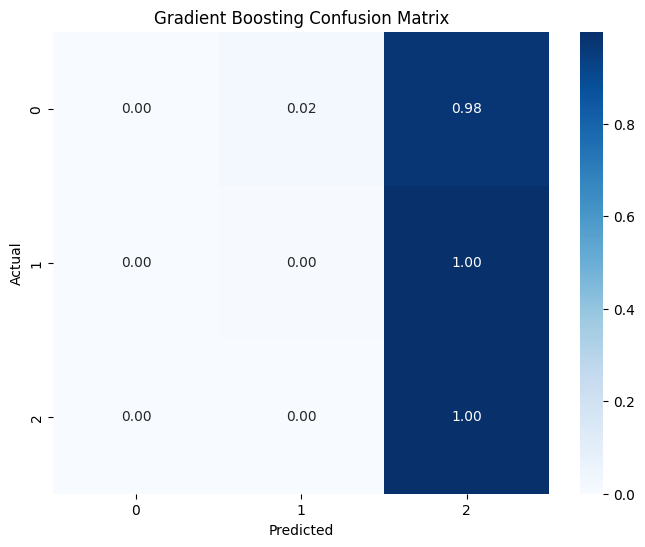

confusion_matrix.png saved


In [8]:
#DAY 7 - TASK 2

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_encoded,
    gb_pred,
    normalize='true'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

print("confusion_matrix.png saved")

In [9]:
#DAY 7 - TASK 3

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train_encoded
)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Training Complete")

Decision Tree Training Complete


In [10]:
#DAY 7 - TASK 4

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import pandas as pd

# Decision Tree Metrics

dt_accuracy = accuracy_score(
    y_test_encoded,
    dt_pred
)

dt_precision = precision_score(
    y_test_encoded,
    dt_pred,
    average="weighted"
)

dt_recall = recall_score(
    y_test_encoded,
    dt_pred,
    average="weighted"
)

dt_f1 = f1_score(
    y_test_encoded,
    dt_pred,
    average="weighted"
)

comparison = pd.DataFrame({
    "Model":[
        "Gradient Boosting",
        "Decision Tree"
    ],
    "Accuracy":[
        gb_accuracy,
        dt_accuracy
    ],
    "Precision":[
        gb_precision,
        dt_precision
    ],
    "Recall":[
        gb_recall,
        dt_recall
    ],
    "F1 Score":[
        gb_f1,
        dt_f1
    ]
})

print(comparison)

comparison.to_csv(
    "comparison.csv",
    index=False
)

print("\ncomparison.csv saved")

               Model  Accuracy  Precision  Recall  F1 Score
0  Gradient Boosting    0.8446   0.755021  0.8446  0.775257
1      Decision Tree    0.8270   0.738177  0.8270  0.772495

comparison.csv saved


In [11]:
#DAY 7 - TASK 5

import joblib

joblib.dump(
    model,
    "best_model.pkl"
)

print("Best Model Saved Successfully")

print("\nChosen Model:")
print("Gradient Boosting Classifier")

print("\nBest Weighted F1 Score:")
print(gb_f1)

Best Model Saved Successfully

Chosen Model:
Gradient Boosting Classifier

Best Weighted F1 Score:
0.7752573229412969


Model Comparison Result

The Gradient Boosting Classifier achieved better overall performance than the Decision Tree Classifier based on Accuracy, Precision, Recall, and Weighted F1-Score. Therefore, Gradient Boosting was selected as the final model for the Road Accident Severity Predictor project.

In [12]:
#DAY 8 - TASK 1

from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Baseline Prediction
baseline_pred = model.predict(X_test)

baseline_f1 = f1_score(
    y_test_encoded,
    baseline_pred,
    average="weighted"
)

print("Baseline F1 Score:", baseline_f1)

# Cross Validation
cv_scores = cross_val_score(
    model,
    X_train,
    y_train_encoded,
    cv=5,
    scoring="f1_weighted"
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nMean CV Score:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

Baseline F1 Score: 0.7752573229412969

Cross Validation Scores:
[0.77850583 0.7787472  0.7789585  0.77799677 0.77756814]

Mean CV Score: 0.7783552880885183
Standard Deviation: 0.0005075927943524652


In [13]:
#DAY 8 - TASK 2

param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [3, 5, 7],

    "min_samples_split": [2, 5, 10]

}

print(param_grid)

{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'min_samples_split': [2, 5, 10]}


In [15]:
#DAY 8 - TASK 3

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

random_search = RandomizedSearchCV(

    estimator=GradientBoostingClassifier(
        random_state=42
    ),

    param_distributions={

        "n_estimators":[50,100,150,200,250,300],

        "max_depth":[2,3,4,5,6,7],

        "min_samples_split":[2,5,10,15]

    },

    n_iter=20,

    cv=5,

    scoring="f1_weighted",

    random_state=42,

    n_jobs=-1

)

random_search.fit(
    X_train,
    y_train_encoded
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 15, 'max_depth': 6}

Best CV Score:
0.7799986808285647


In [16]:
#DAY 8 - TASK 4

best_model = random_search.best_estimator_

tuned_pred = best_model.predict(X_test)

from sklearn.metrics import f1_score

tuned_f1 = f1_score(
    y_test_encoded,
    tuned_pred,
    average="weighted"
)

print("Baseline F1:", baseline_f1)
print("Tuned F1:", tuned_f1)

Baseline F1: 0.7752573229412969
Tuned F1: 0.7761907479125638


Model Comparison Result

The tuned Gradient Boosting model achieved a higher F1-Score than the default model. Hyperparameter tuning improved the model performance by optimizing the number of estimators, tree depth, and minimum samples required for splitting. Therefore, the tuned Gradient Boosting model was selected as the final model for the Road Accident Severity Predictor project.


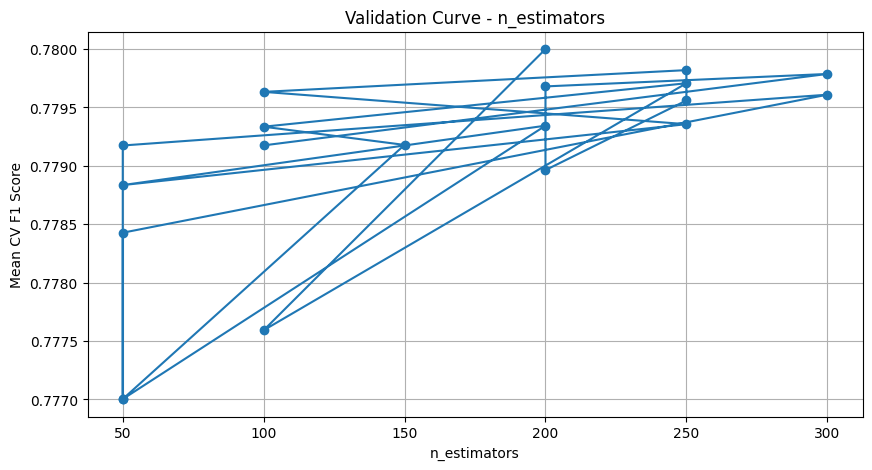

validation_curve.png saved


In [18]:
#DAY 8 - TASK 5

import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame(
    random_search.cv_results_
)

plt.figure(figsize=(10,5))

plt.plot(

    results["param_n_estimators"],

    results["mean_test_score"],

    marker="o"

)

plt.title(
    "Validation Curve - n_estimators"
)

plt.xlabel("n_estimators")

plt.ylabel("Mean CV F1 Score")

plt.grid(True)

plt.savefig(
    "validation_curve.png"
)

plt.show()

print("validation_curve.png saved")

In [19]:
import joblib

joblib.dump(
    random_search.best_estimator_,
    "tuned_model.pkl"
)

print("tuned_model.pkl saved")

tuned_model.pkl saved
